In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
result_path = '/content/drive/MyDrive/Dataset/Parkinson/Result/'

# Load data

In [ ]:
# Load your dataset (Assuming it's in a CSV file)
df = pd.read_csv('/content/ParkinsonVoiceBank (1) (1).csv')


In [ ]:
# In df there is a column name 'id' where the values are string seprate by underscore, create a new column 'group' by extracting string before underscore

df['group'] = df['id'].str.split('_').str[0]


In [ ]:
df

,id,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,locAbsJitter,rapJitter,ppq5Jitter,ddpJitter,...,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,class,group
0,PD1_1,379.850000,378.780000,0.005821,0.000061,0.001113,0.000006,0.000139,0.000342,0.000407,...,-0.022249,-0.015977,-0.020003,0.056461,-0.123634,-0.054068,0.041115,-0.129016,1,PD1
1,PD1_2,295.320000,294.250000,0.007479,0.000090,0.001755,0.000012,0.000289,0.000717,0.000856,...,0.059450,-0.263631,-0.077017,0.068164,0.116384,-0.134152,0.027960,-0.014747,1,PD1
2,PD1_3,260.010000,258.940000,0.008504,0.000110,0.002301,0.000018,0.000460,0.000995,0.001391,...,0.021635,-0.229297,0.035860,0.210961,0.140791,-0.141933,0.113381,0.069652,1,PD1
3,PD1_4,269.640000,268.570000,0.008184,0.000072,0.001937,0.000015,0.000374,0.000984,0.001134,...,0.021698,-0.269088,-0.088488,0.065214,0.146569,-0.079391,0.057175,-0.027580,1,PD1
4,PD1_5,318.860000,317.790000,0.006943,0.000041,0.000952,0.000006,0.000193,0.000428,0.000567,...,-0.076888,-0.094564,-0.035197,0.027945,-0.009019,-0.004599,-0.088763,-0.073001,1,PD1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,HC60_3,225.264960,224.217216,0.009414,0.000086,0.001205,0.000011,0.000346,0.000702,0.001027,...,-0.122068,-0.163046,0.024090,0.109826,0.045094,-0.091929,-0.028851,0.031887,0,HC60
896,HC60_4,192.086400,191.059200,0.010630,0.000093,0.002886,0.000030,0.001068,0.001972,0.003215,...,-0.039273,-0.202289,-0.103237,0.112245,0.133926,-0.080233,-0.089146,0.156249,0,HC60
897,HC60_5,337.948800,336.921600,0.006025,0.000031,0.000750,0.000004,0.000154,0.000349,0.000452,...,0.026690,-0.055757,0.147399,0.063768,-0.017146,-0.047161,0.010439,-0.015682,0,HC60
898,HC60_6,298.915200,297.888000,0.006809,0.000086,0.001582,0.000010,0.000267,0.000657,0.000791,...,0.068852,-0.112962,-0.183688,0.060804,0.055411,-0.053467,0.014019,-0.059784,0,HC60


In [ ]:
#  how many 1 and 0 samples in df['class']

print(df['class'].value_counts())


class
1    450
0    450
Name: count, dtype: int64


#Descriptive statistics

In [ ]:
# prompt: generate mean and standard deviation for each of the column in df_stat for class=0(named as HC) and class=1 (named as PD). store them in a CSV file where each row is the column/feature name of df_stat, the columns would be PD_Mean, PD_SD, HC_Mean and HC_SD

df_stat = df.drop(['id','class'],axis=1)
# Separate data for HC and PD
df_HC = df[df['class'] == 0]
df_PD = df[df['class'] == 1]

# Calculate mean and standard deviation for each column for both classes
stats = []
for col in df_stat.columns:
    pd_mean = df_PD[col].mean()
    pd_std = df_PD[col].std()
    hc_mean = df_HC[col].mean()
    hc_std = df_HC[col].std()
    stats.append([col, pd_mean, pd_std, hc_mean, hc_std])

# Create a DataFrame from the statistics
stats_df = pd.DataFrame(stats, columns=['Feature', 'PD_Mean', 'PD_SD', 'HC_Mean', 'HC_SD'])

# Save the statistics to a CSV file
stats_df.to_csv('/content/drive/MyDrive/stats.csv', index=False)
stats_df


TypeError: Could not convert string 'PD1PD1PD1PD1PD1PD1PD1PD1PD2PD2PD2PD2PD2PD2PD2PD2PD3PD3PD3PD3PD3PD3PD3PD3PD4PD4PD4PD4PD4PD4PD4PD4PD5PD5PD5PD5PD5PD5PD5PD5PD6PD6PD6PD6PD6PD6PD6PD6PD7PD7PD7PD7PD7PD7PD7PD7PD8PD8PD8PD8PD8PD8PD8PD8PD9PD9PD9PD9PD9PD9PD9PD9PD10PD10PD10PD10PD10PD10PD10PD10PD11PD11PD11PD11PD11PD11PD11PD11PD12PD12PD12PD12PD12PD12PD12PD12PD13PD13PD13PD13PD13PD13PD13PD13PD14PD14PD14PD14PD14PD14PD14PD14PD15PD15PD15PD15PD15PD15PD15PD15PD16PD16PD16PD16PD16PD16PD16PD16PD17PD17PD17PD17PD17PD17PD17PD17PD18PD18PD18PD18PD18PD18PD18PD18PD19PD19PD19PD19PD19PD19PD19PD19PD20PD20PD20PD20PD20PD20PD20PD20PD21PD21PD21PD21PD21PD21PD21PD21PD22PD22PD22PD22PD22PD22PD22PD22PD23PD23PD23PD23PD23PD23PD23PD23PD24PD24PD24PD24PD24PD24PD24PD24PD25PD25PD25PD25PD25PD25PD25PD25PD26PD26PD26PD26PD26PD26PD26PD26PD27PD27PD27PD27PD27PD27PD27PD27PD28PD28PD28PD28PD28PD28PD28PD28PD29PD29PD29PD29PD29PD29PD29PD29PD30PD30PD30PD30PD30PD30PD30PD30PD31PD31PD31PD31PD31PD31PD31PD32PD32PD32PD32PD32PD32PD32PD33PD33PD33PD33PD3

# t-SNE visualization

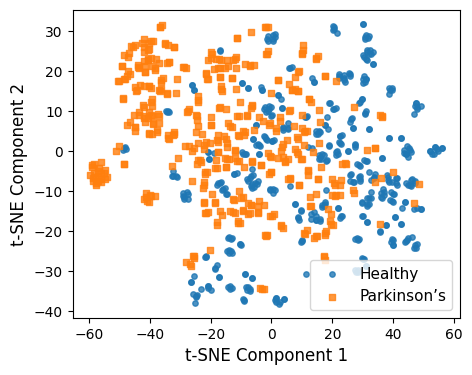

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Load your dataset
# df = pd.read_csv("/content/ParkinsonVoiceBank (1) (1).csv")  # Uncomment if loading from CSV

# Separate features and labels
X = df.drop(columns=['class','id'])  # Replace 'label' with the actual column name of the labels
y = df['class']  # The class labels (0: Healthy, 1: Parkinson's)

# Normalize features for better t-SNE results
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42,perplexity = 30)  # Adjust perplexity if needed
X_tsne = tsne.fit_transform(X_scaled)

# Plot results
# plt.figure(figsize=(8, 6))
plt.figure(figsize=(5, 4))
# Scatter plot for class 0 (Healthy) with marker 'o'
plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1],
                     marker='o',
                     alpha=0.8, s=15, label='Healthy')

# Scatter plot for class 1 (Parkinson's) with marker 's'
plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1],
            marker='s',
            alpha=0.8, s=13, label='Parkinson’s')

# scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', marker=['o','s'], alpha=0.7, s=15)
# plt.legend(handles=scatter.legend_elements()[0], fontsize=8,labels=['Healthy', 'Parkinson’s'])

plt.xlabel("t-SNE Component 1",fontsize=12)
plt.ylabel("t-SNE Component 2",fontsize=12)
# plt.title("t-SNE Visualization of Parkinson's vs. Healthy")
plt.legend(fontsize=11)

# Save as PDF
plt.savefig(result_path+"tSNE_Visualization.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("tSNE_Visualization.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

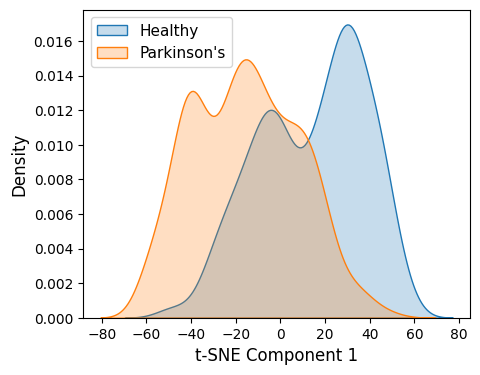

In [ ]:
import seaborn as sns

# Visualize the distribution of t-SNE component 1 for each class using seaborn
plt.figure(figsize=(5, 4))
sns.kdeplot(X_tsne[y == 0, 0], label="Healthy", fill=True)
sns.kdeplot(X_tsne[y == 1, 0], label="Parkinson's", fill=True)
plt.xlabel("t-SNE Component 1",fontsize=12)
plt.ylabel("Density",fontsize=12)
# plt.title("Distribution of t-SNE Component 1 for Healthy and Parkinson's")
plt.legend(fontsize=11)
plt.savefig(result_path+"tSNE1_dist.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

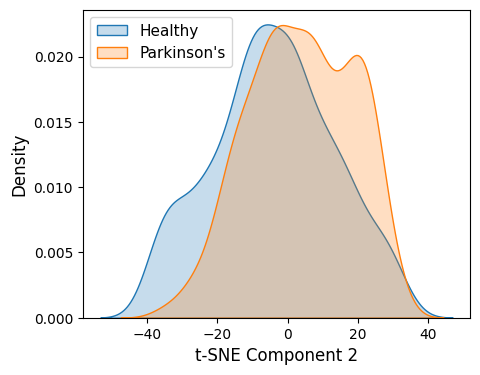

In [ ]:
import seaborn as sns

# Visualize the distribution of t-SNE component 1 for each class using seaborn
plt.figure(figsize=(5, 4))
sns.kdeplot(X_tsne[y == 0, 1], label="Healthy", fill=True)
sns.kdeplot(X_tsne[y == 1, 1], label="Parkinson's", fill=True)
plt.xlabel("t-SNE Component 2",fontsize=12)
plt.ylabel("Density",fontsize=12)
# plt.title("Distribution of t-SNE Component 1 for Healthy and Parkinson's")
plt.legend(fontsize=11)
plt.savefig(result_path+"tSNE2_dist.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#  calculate t-SNE component ffrom df_stat for class =1 (label as 'Parkinson's') and class=0 (label as 'Healthy') and visualize

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Assuming df_stat is your DataFrame with statistical features and 'class' column
# Replace 'df_stat' with the actual name of your DataFrame if different
df_stat = df.drop(columns=['id'])  # Using the loaded DataFrame 'df' as df_stat for demonstration

# Separate data for class 0 (HC) and class 1 (PD)
df_class_HC = df_stat[df_stat['class'] == 0]
df_class_PD = df_stat[df_stat['class'] == 1]


# Select features (excluding non-numeric features and the 'class' column)
# Replace 'your_features' with a list of the actual column names to be used
your_features = df.select_dtypes(include=np.number).columns.tolist()
if 'class' in your_features:
  your_features.remove('class')

X_class_HC = df_class_HC[your_features].values
X_class_PD = df_class_PD[your_features].values

# Normalize features for better t-SNE results
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)  # Adjust random_state for reproducibility

X_tsne_class_HC = tsne.fit_transform(scaler.fit_transform(X_class_HC))
X_tsne_class_PD = tsne.fit_transform(scaler.fit_transform(X_class_PD))

# Visualize the t-SNE components
plt.figure(figsize=(5.2, 4))
plt.scatter(X_tsne_class_HC[:, 0], X_tsne_class_HC[:, 1], label="Healthy", alpha=0.7,marker='o', s=15)
plt.scatter(X_tsne_class_PD[:, 0], X_tsne_class_PD[:, 1], label="Parkinson's",alpha=0.7, marker='s', s=13)
plt.xlabel("t-SNE Component 1",fontsize=10)
plt.ylabel("t-SNE Component 2",fontsize=10)
# plt.title("t-SNE Visualization of Parkinson's vs. Healthy")
plt.legend(fontsize=8)
plt.savefig(result_path+"tSNE_Visualization.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


# Statistical significance testing

In [ ]:
# drop 'id' column from df

df_stat = df.drop(columns=['id'])


In [ ]:
#  perform normality test for each of the column values with class=1 and class=0 in df_stat using Shapiro-Wilk test

from scipy.stats import shapiro

# Separate data by class
df_stat_class_1 = df_stat[df_stat['class'] == 1]
df_stat_class_0 = df_stat[df_stat['class'] == 0]

# Perform Shapiro-Wilk test for each column for class 1
print("Normality test results for class 1:")
for column in df_stat_class_1.columns:
    if column != 'class' and column != 'group':
        statistic, p_value = shapiro(df_stat_class_1[column])
        print(f"Column: {column}")
        print(f"Statistic: {statistic:.4f}")
        print(f"P-value: {p_value:.4f}")
        if p_value > 0.05:
            print("Data appears normally distributed")
        else:
            print("Data does not appear normally distributed")
        print("---")

# Perform Shapiro-Wilk test for each column for class 0
print("\nNormality test results for class 0:")
for column in df_stat_class_0.columns:
    if column != 'class' and column != 'group':
        statistic, p_value = shapiro(df_stat_class_0[column])
        print(f"Column: {column}")
        print(f"Statistic: {statistic:.4f}")
        print(f"P-value: {p_value:.4f}")
        if p_value > 0.05:
            print("Data appears normally distributed")
        else:
            print("Data does not appear normally distributed")
        print("---")


In [ ]:
#  perform normality test for each of the column values with class=1 and class=0 in df_stat using Shapiro-Wilk test, generate and print a list of column names that normally distributed for class 1 (which can be named as PD) and class 0 (which can be named as HC)

# Lists to store normally distributed columns for each class
normally_distributed_cols_class_1 = []
normally_distributed_cols_class_0 = []

# Normality test for class 1
for column in df_stat_class_1.columns:
    if column not in ['class', 'group']:
        statistic, p_value = shapiro(df_stat_class_1[column])
        if p_value > 0.05:
            normally_distributed_cols_class_1.append(column)

# Normality test for class 0
for column in df_stat_class_0.columns:
    if column not in ['class', 'group']:
        statistic, p_value = shapiro(df_stat_class_0[column])
        if p_value > 0.05:
            normally_distributed_cols_class_0.append(column)

# Print the results
print("Normally distributed columns for class 1 (PD):", normally_distributed_cols_class_1)
print("Normally distributed columns for class 0 (HC):", normally_distributed_cols_class_0)


Normally distributed columns for class 1 (PD): ['f1', 'f4', 'Delta_MFCC_1', 'Delta_MFCC_2', 'Delta_MFCC_6', 'Delta_MFCC_7', 'Delta_MFCC_9', 'Delta_MFCC_12', 'MFCC_1', 'MFCC_2', 'MFCC_6', 'MFCC_7', 'MFCC_9', 'MFCC_12']
Normally distributed columns for class 0 (HC): []


In [ ]:
#   apply Mann-Whitney U test for each of the column in df_stat to evaluate whether there is statistical significance between class =1 and class=0 column values, and save the relevant result values such as U, Z, r and p, for each column as row in a CSV file

from scipy.stats import mannwhitneyu

results = []
for col in df_stat.columns:
    if col not in ['class', 'group']:
        group1 = df_stat[df_stat['class'] == 1][col]
        group0 = df_stat[df_stat['class'] == 0][col]
        U, p = mannwhitneyu(group1, group0)
        # Calculate Z-score and effect size (r)
        n1 = len(group1)
        n2 = len(group0)
        z = (U - (n1 * n2) / 2) / np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
        r = z / np.sqrt(n1 + n2)

        results.append([col, U, z, r, p])

results_df = pd.DataFrame(results, columns=['Column', 'U', 'Z', 'r', 'p'])
results_df.to_csv('/content/drive/My Drive/mann_whitney_results.csv', index=False)


In [ ]:
results_df

In [ ]:
!pip install --upgrade scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 21.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


In [ ]:
#: generate results applying the Bonferroni correction

from statsmodels.stats.multitest import multipletests

# Assuming 'results_df' is your DataFrame from the previous code
alpha = 0.05
reject, p_corrected, _, _ = multipletests(results_df['p'], method='bonferroni', alpha=alpha)

results_df['p_corrected'] = p_corrected
results_df['reject'] = reject

results_df.to_csv('/content/drive/My Drive/mann_whitney_results_bonferroni.csv', index=False)
results_df


,Column,U,Z,r,p,p_corrected,reject
0,numPulses,63579.0,-9.661017,-0.322034,4.418075e-22,3.136834e-20,True
1,numPeriodsPulses,63505.5,-9.679867,-0.322662,3.674890e-22,2.609172e-20,True
2,meanPeriodPulses,139373.0,9.776936,0.325898,1.416037e-22,1.005386e-20,True
3,stdDevPeriodPulses,137105.5,9.195418,0.306514,3.739357e-20,2.654943e-18,True
4,locPctJitter,148767.0,12.186100,0.406203,3.689678e-34,2.619671e-32,True
...,...,...,...,...,...,...,...
66,MFCC_8,112703.0,2.937210,0.097907,3.313163e-03,2.352346e-01,False
67,MFCC_9,117605.0,4.194365,0.139812,2.737905e-05,1.943912e-03,True
68,MFCC_10,100844.0,-0.104122,-0.003471,9.171744e-01,1.000000e+00,False
69,MFCC_11,108667.0,1.902147,0.063405,5.716871e-02,1.000000e+00,False


# Data preprocessing

In [ ]:
# Define features, class labels, and group identifiers
X_df = df.drop(columns=['id','class', 'group'])  # All features except 'class' and 'group'
y = df['class'].values  # Target variable
groups = df['group'].values  # Group identifier

In [ ]:
# Normalize the feature values
scaler = StandardScaler()
X = scaler.fit_transform(X_df)

#Core functions

##Classifiers

In [ ]:
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM (RBF)': SVC(probability=True,random_state=42),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'MLP': MLPClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42), # good for binary classification
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

## Calculate confidence interval

In [ ]:
def mean_ci(scores):
    """Calculate mean and 95% CI for a list/array of scores."""
    mean = np.mean(scores)
    se = np.std(scores, ddof=1) / np.sqrt(len(scores))
    ci = 1.96 * se
    return mean, ci

##Evaluate classifiers

In [ ]:
from sklearn.metrics import make_scorer, confusion_matrix

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

specificity = make_scorer(specificity_score)

In [ ]:
# Define scoring as a dictionary for custom and predefined metrics
scoring = {
        'accuracy': 'accuracy',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'specificity': specificity,  # Use the make_scorer object
        'precision': 'precision',
        'recall': 'recall'}

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
def evaluate_classifiers(X, y, groups, selected_features, classifiers, n_splits=10):
    group_kfold = GroupKFold(n_splits=n_splits)
    results = {}

    for name, clf in classifiers.items():
        print(f"\nModel: {name}")
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', clf)
        ])

        # scoring = ['accuracy', 'f1', 'roc_auc', specificity, 'precision', 'recall']
        cv_results = cross_validate(
            pipeline, X[selected_features], y,
            groups=groups, cv=group_kfold,
            scoring=scoring,
            return_train_score=False
        )

        # Access results
        acc_scores = cv_results['test_accuracy']
        f1_scores = cv_results['test_f1']
        auc_scores = cv_results['test_roc_auc']
        specificity_scores = cv_results['test_specificity']
        precision_scores = cv_results['test_precision']
        recall_scores = cv_results['test_recall']

        # Compute your summary stats
        acc_mean, acc_ci = mean_ci(acc_scores)
        f1_mean, f1_ci = mean_ci(f1_scores)
        auc_mean, auc_ci = mean_ci(auc_scores)
        specificity_mean, specificity_ci = mean_ci(specificity_scores)
        precision_mean, precision_ci = mean_ci(precision_scores)
        recall_mean, recall_ci = mean_ci(recall_scores)

        # Store results
        results[name] = {
            'Classifier': name,
            'Accuracy': acc_mean,
            'Accuracy_ci': acc_ci,
            'AUC': auc_mean,
            'AUC_ci': auc_ci,
            'F1 Score': f1_mean,
            'F1 Score_ci': f1_ci,
            'Precision': precision_mean,
            'Precision_ci': precision_ci,
            'Recall': recall_mean,
            'Recall_ci': recall_ci,
            'Specificity': specificity_mean,
            'Specificity_ci': specificity_ci
        }

        # Print metrics
        print(f"  Accuracy: {acc_mean:.4f} ± {acc_ci:.4f}")
        print(f"  F1 Score: {f1_mean:.4f} ± {f1_ci:.4f}")
        print(f"  AUC:      {auc_mean:.4f} ± {auc_ci:.4f}")
        print(f"  Precision: {precision_mean:.4f} ± {precision_ci:.4f}")
        print(f"  Recall: {recall_mean:.4f} ± {recall_ci:.4f}")
        print(f"  Specificity: {specificity_mean:.4f} ± {specificity_ci:.4f}")

        # Get cross-validated predictions (mimics cross_validate)
        y_pred = cross_val_predict(
            pipeline, X[selected_features], y,groups=groups, cv=group_kfold)
        # Compute the confusion matrix
        cm = confusion_matrix(y, y_pred)

        # Flatten confusion matrix
        labels = np.unique(y)
        cm_flat = cm.flatten()

        # Generate keys like: 'Confusion_cm_00', 'Confusion_cm_01', ...
        confusion_keys = [f"Confusion_cm_{i}{j}" for i in range(len(labels)) for j in range(len(labels))]

        # Combine with results
        for key, value in zip(confusion_keys, cm_flat):
            results[name][key] = value  # No tuple needed, just raw values

        # Display the confusion matrix
        # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Health control','Parkinson\'s'])
        # disp.plot(cmap='Blues')
        # plt.title("Confusion Matrix")
        # plt.show()

    return results

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
def evaluate_a_classifiers(X, y, groups, selected_features, classifier, n_splits=10):
    group_kfold = GroupKFold(n_splits=n_splits)
    results = {}

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', classifier)
    ])

    cv_results = cross_validate(
        pipeline, X[selected_features], y,
        groups=groups, cv=group_kfold,
        scoring=scoring,
        return_train_score=False
    )

    # Access results
    acc_scores = cv_results['test_accuracy']
    f1_scores = cv_results['test_f1']
    auc_scores = cv_results['test_roc_auc']
    specificity_scores = cv_results['test_specificity']
    precision_scores = cv_results['test_precision']
    recall_scores = cv_results['test_recall']

    # Compute your summary stats
    acc_mean, acc_ci = mean_ci(acc_scores)
    f1_mean, f1_ci = mean_ci(f1_scores)
    auc_mean, auc_ci = mean_ci(auc_scores)
    specificity_mean, specificity_ci = mean_ci(specificity_scores)
    precision_mean, precision_ci = mean_ci(precision_scores)
    recall_mean, recall_ci = mean_ci(recall_scores)

    # Store results
    results = {
        'Accuracy': acc_mean,
        'Accuracy_ci': acc_ci,
        'AUC': auc_mean,
        'AUC_ci': auc_ci,
        'F1 Score': f1_mean,
        'F1 Score_ci': f1_ci,
        'Precision': precision_mean,
        'Precision_ci': precision_ci,
        'Recall': recall_mean,
        'Recall_ci': recall_ci,
        'Specificity': specificity_mean,
        'Specificity_ci': specificity_ci
    }

    # Print metrics
    # print(f"  Accuracy: {acc_mean:.4f} ± {acc_ci:.4f}")
    # print(f"  F1 Score: {f1_mean:.4f} ± {f1_ci:.4f}")
    # print(f"  AUC:      {auc_mean:.4f} ± {auc_ci:.4f}")
    # print(f"  Precision: {precision_mean:.4f} ± {precision_ci:.4f}")
    # print(f"  Recall: {recall_mean:.4f} ± {recall_ci:.4f}")
    # print(f"  Specificity: {specificity_mean:.4f} ± {specificity_ci:.4f}")

    # Get cross-validated predictions (mimics cross_validate)
    # y_pred = cross_val_predict(
    #     pipeline, X[selected_features], y,groups=groups, cv=group_kfold)
    # Compute the confusion matrix
    # cm = confusion_matrix(y, y_pred)

    # Flatten confusion matrix
    # labels = np.unique(y)
    # cm_flat = cm.flatten()

    # Generate keys like: 'Confusion_cm_00', 'Confusion_cm_01', ...
    # confusion_keys = [f"Confusion_cm_{i}{j}" for i in range(len(labels)) for j in range(len(labels))]

    # Combine with results
    # for key, value in zip(confusion_keys, cm_flat):
    #     results[key] = value  # No tuple needed, just raw values

    # Display the confusion matrix
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Health control','Parkinson\'s'])
    # disp.plot(cmap='Blues')
    # plt.title("Confusion Matrix")
    # plt.show()

    return results

##Compute performance metrics

In [ ]:
def compute_metrics(y_true, y_pred_probs):
    y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary labels

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)  # Sensitivity
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_probs)

    # Compute Specificity from confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    return acc, precision, recall, specificity, f1, roc_auc

##Save results

In [ ]:
def save_results(results, file_name):
  # Create a list to store the data for the CSV
  csv_data = []

  # Iterate through the results dictionary
  for classifier_name, metrics in results.items():
      # Extract the accuracy, f1, and AUC metrics (and their confidence intervals)
      accuracy_mean, accuracy_ci = metrics['Accuracy']
      f1_mean, f1_ci = metrics['F1 Score']
      auc_mean, auc_ci = metrics['AUC']

      # Append a row of data for each classifier
      csv_data.append([
          classifier_name,
          accuracy_mean, accuracy_ci,
          f1_mean, f1_ci,
          auc_mean, auc_ci
      ])

  # Create a pandas DataFrame from the collected data
  results_df = pd.DataFrame(csv_data, columns=[
      'Classifier', 'Accuracy_Mean', 'Accuracy_CI',
      'F1_Score_Mean', 'F1_Score_CI',
      'AUC_Mean', 'AUC_CI'
  ])

  # Save the DataFrame to a CSV file
  results_df.to_csv(file_name, index=False)


#Hyperparameter tuning

In [ ]:
# Step 2: Evaluate classifiers with GroupKFold on selected features
results = evaluate_classifiers(X_df, y, groups,list(X_df.columns), classifiers_hp_tuned)

# Step 3: Report best classifier
best_clf = max(results, key=lambda clf: results[clf]['Accuracy'][0])  # Get classifier with max accuracy
print(f"\nBest classifier: {best_clf} with accuracy: {results[best_clf]['Accuracy'][0]:.4f}")

NameError: name 'classifiers_hp_tuned' is not defined

In [ ]:
# save_results(results,result_path+'all71features-defaultClassifiers-results.csv')

In [ ]:
param_grids = {
    'Logistic Regression':{
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': np.logspace(-4, 4, 10),
    'solver': ['liblinear', 'saga'],
    'l1_ratio': np.linspace(0, 1, 5),  # Only used if penalty='elasticnet'
     # 'class_weight': [None, 'balanced'], # we got balanced class
    'max_iter': [100, 200, 500, 1000]
    },
    'Random Forest':{
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    # 'class_weight': ['balanced', None],
    'bootstrap': [True, False]
},
    'SVM (RBF)':{
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3, 4],  # Only used if kernel='poly'
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
},
    'KNN':{
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [20, 30, 40],
    'p': [1, 2]  # Manhattan vs. Euclidean
},
    'Gradient Boosting':{
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.85, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2', None]
},
    'Decision Tree':{
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    # 'class_weight': [None, 'balanced'],
    'ccp_alpha': [0.0, 0.01, 0.1]
},
    'MLP':{
    'hidden_layer_sizes': [(100,), (50, 50), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'early_stopping': [True],
},
    'XGBoost': {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'gamma': [0, 0.1],
    'min_child_weight': [1, 5],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 10]
    },
    'AdaBoost': {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'estimator': [DecisionTreeClassifier(max_depth=1),
                  DecisionTreeClassifier(max_depth=2),
                  RandomForestClassifier(n_estimators=100, random_state=42),
                  RandomForestClassifier(n_estimators=300, random_state=42)
                  ]
    # ,'algorithm': ['SAMME', 'SAMME.R']
}
}

In [ ]:
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# Cross-validation and results collection
cv = GroupKFold(n_splits=10)
results = []

for name, clf in classifiers.items():
    print(f"\n🔍 Tuning {name}...")

    # Use a pipeline with StandardScaler if needed
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])

    modified_param_grid = {'clf__' + key: value for key, value in param_grids[name].items()}

    # Step 3: Create the randomized search with random_state
    search = RandomizedSearchCV(
    pipe,
    param_distributions=modified_param_grid,
    n_iter=30,
    cv=cv, scoring = scoring, refit='accuracy',
    random_state=42,  # <--- important!
    n_jobs=-1) # return_train_score=True

    # search = GridSearchCV(pipe, modified_param_grid, cv=cv, scoring=scoring, refit='accuracy', n_jobs=-1)
    search.fit(X_df, y, groups=groups)


    cleaned_params = {
    key.split('__')[1]: value
    for key, value in search.best_params_.items()
    if key.startswith('clf__')
    }

    print(f"✅ Best Score: {search.best_score_:.4f}")
    print(f"🏆 Best Params: {cleaned_params}")

    results.append({
        'Classifier': name,
        'best_score': search.best_score_,
        'params': cleaned_params,
        'accuracy': search.cv_results_['mean_test_accuracy'],
        'f1': search.cv_results_['mean_test_f1'],
        'roc_auc': search.cv_results_['mean_test_roc_auc'],
        'specificity': search.cv_results_['mean_test_specificity'],
        'precision': search.cv_results_['mean_test_precision'],
        'recall': search.cv_results_['mean_test_recall']
    })

In [ ]:
res = evaluate_classifiers(X_df, y, groups,list(X_df.columns), classifiers)

In [ ]:
# Results summary
df_results = pd.DataFrame(res).T
print("\n📊 Summary of Best Models:")
print(df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))

In [ ]:
df_results

In [ ]:
# df_results.to_csv(result_path+'hpTuning-randomSearch-20iter-results.csv', index=False)

##Hyper-tuned classifier

In [ ]:
classifiers_hp_tuned = {
    'Logistic Regression': LogisticRegression(solver='liblinear', penalty ='l2', max_iter=1000, C=10000.0,
        random_state=42), #l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
    # 'Random Forest': RandomForestClassifier(n_estimators=500, min_samples_split=2, min_samples_leaf=2, max_features='log2', max_depth=50, bootstrap=False,
        # random_state=42)
    # 'SVM (RBF)': SVC(kernel='poly', gamma='scale', degree=3, C=100,
                    #  probability=True, random_state=42),
    'KNN': KNeighborsClassifier(weights='distance', p=1, n_neighbors=3, leaf_size=30, algorithm='brute'),

    # 'Gradient Boosting': GradientBoostingClassifier(subsample=0.85, n_estimators= 300, min_samples_split=2, min_samples_leaf=1, max_features='log2', max_depth=5, learning_rate=0.1,
        # random_state=42),
    'Decision Tree': DecisionTreeClassifier(min_samples_split=2, min_samples_leaf=1, max_features=None, max_depth=10, criterion='gini', ccp_alpha=0.0,
        random_state=42),
    'MLP': MLPClassifier(solver='adam', learning_rate_init=0.01, learning_rate='constant', hidden_layer_sizes= (100,), early_stopping=True, alpha=0.001, activation='relu',
        random_state=42),
    'XGBoost': XGBClassifier(subsample=0.7, reg_lambda=1, reg_alpha=0, n_estimators=500, min_child_weight=1, max_depth=6, learning_rate=0.1, gamma=0, colsample_bytree=1.0,
        eval_metric='logloss', random_state=42) # good for binary classification
    # 'AdaBoost': AdaBoostClassifier(n_estimators=50, learning_rate=0.5, estimator=RandomForestClassifier(n_estimators=300, random_state=42),
        # random_state=42)
}

In [ ]:
# classifiers_hp_tuned = {
#     'Logistic Regression': LogisticRegression(solver='liblinear', penalty ='l2', max_iter=100, C=10000.0,
#         random_state=42),
#         'Decision Tree': DecisionTreeClassifier(min_samples_split=2, min_samples_leaf=1, max_features=None, max_depth=10, criterion='gini', ccp_alpha=0.0,
#         random_state=42)
    # , #l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
        # 'SVM (RBF)': SVC(kernel='poly', gamma='scale', degree=3, C=100,
                    #  probability=True, random_state=42)
}

In [ ]:
# final_model = XGBClassifier(
#     **cleaned_params,
#     objective='binary:logistic',
#     random_state=42
# )

In [ ]:
final_model = AdaBoostClassifier(n_estimators=50, learning_rate=0.5, estimator=RandomForestClassifier(n_estimators=300, random_state=42),
        random_state=42)

In [ ]:
r = evaluate_a_classifiers(X_df, y, groups, list(X_df.columns), final_model, n_splits=10)

In [ ]:
# Results summary
df_results = pd.DataFrame([r])
print("\n📊 Summary of Best Models:")
print(df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))


📊 Summary of Best Models:
   Accuracy  Accuracy_ci       AUC    AUC_ci  F1 Score  F1 Score_ci  \
0  0.942222      0.01206  0.943555  0.011924  0.940299     0.014871   

   Precision  Precision_ci    Recall  Recall_ci  Specificity  Specificity_ci  \
0   0.949583      0.022766  0.932154   0.017848     0.954956        0.016235   

   Confusion_cm_00  Confusion_cm_01  Confusion_cm_10  Confusion_cm_11  
0              429               21               31              419  


In [ ]:
# !pip install --upgrade xgboost

In [ ]:
group_kfold = GroupKFold(n_splits=10)
fold_scores = []
for train_idx, val_idx in group_kfold.split(X, y, groups):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    final_model.fit(X_train, y_train)
    score = final_model.score(X_val, y_val)
    fold_scores.append(score)
    print(f"Fold score: {score:.4f}")

average_score = np.mean(fold_scores)
print(f"\nAverage score across folds: {average_score:.4f}")

NameError: name 'final_model' is not defined

In [ ]:
# After grid.best_params_ is found
# final_model = XGBClassifier(
#     **grid.best_params_,
#     n_estimators=1000,
#     objective='binary:logistic',
#     random_state=42
# )

#Feature Selection and Ranking

##LASSO

In [ ]:
# =========================
# 🔧 IMPORTS
# =========================
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.base import clone
from scipy import stats

# Models
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# =========================
# 🔗 MOUNT DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/Parkinson_Results_LASSO/"
os.makedirs(save_path, exist_ok=True)

# =========================
# 📥 LOAD DATA
# =========================
df = pd.read_csv("/content/BenSParX.csv")

groups = df["id"]
X = df.drop(columns=["class", "id"])
y = df["class"]

# =========================
# 🔁 CV SETUP
# =========================
outer_cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# ⚙️ MODELS (BEST PARAMS)
# =========================
models = {
    "LR": LogisticRegression(C=10000, solver="liblinear", max_iter=100),

    "DT": DecisionTreeClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=1, random_state=42),

    "RF": RandomForestClassifier(
        n_estimators=500, max_depth=50, min_samples_split=2,
        min_samples_leaf=2, max_features="log2", bootstrap=False, random_state=42
    ),

    "SVM": SVC(C=100, kernel="poly", degree=3, gamma="scale", probability=True),

    "GB": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=5,
        subsample=0.85, min_samples_split=2, min_samples_leaf=1, random_state=42
    ),

    "XGB": XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        subsample=0.7, colsample_bytree=1.0,
        gamma=0, min_child_weight=1, reg_lambda=1,
        eval_metric="logloss", random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=42),

    "KNN": KNeighborsClassifier(n_neighbors=3, weights="distance", algorithm="brute", p=1),

    "MLP": MLPClassifier(hidden_layer_sizes=(100,), activation="relu",
                         solver="adam", alpha=0.001, max_iter=500, random_state=42)
}

# =========================
# 📊 METRICS FUNCTION
# =========================
def compute_all_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "auc": roc_auc_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred) * 100,
        "recall": recall_score(y_true, y_pred) * 100,
        "f1": f1_score(y_true, y_pred) * 100,
        "specificity": (tn / (tn + fp)) * 100
    }

# =========================
# 📦 STORAGE
# =========================
results = []
sample_results = []
feature_store = []

# =========================
# 🔄 NESTED CV
# =========================
fold_id = 1

for train_idx, test_idx in outer_cv.split(X, y, groups):

    print(f"\n🔁 Fold {fold_id}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ======================================
    # 🔹 LASSO FEATURE SELECTION
    # ======================================
    print("   🔍 LASSO Feature Selection")

    lasso = LogisticRegressionCV(
        Cs=10,
        cv=inner_cv,
        penalty='l1',
        solver='liblinear',
        scoring='accuracy',
        max_iter=1000,
        n_jobs=-1
    )

    lasso.fit(X_train, y_train)

    coef = lasso.coef_[0]
    selected_features = list(X.columns[coef != 0])

    # Fallback (if LASSO removes all features)
    if len(selected_features) == 0:
        selected_features = list(X.columns)

    print(f"   ✅ Selected Features: {len(selected_features)}")

    feature_store.append({
        "fold": fold_id,
        "method": "LASSO",
        "num_features": len(selected_features),
        "features": ",".join(selected_features)
    })

    # ======================================
    # 🔹 TRAIN ALL MODELS
    # ======================================
    for model_name, model in models.items():

        clf = clone(model)
        clf.fit(X_train[selected_features], y_train)

        y_pred = clf.predict(X_test[selected_features])
        y_prob = clf.predict_proba(X_test[selected_features])[:, 1]

        metrics = compute_all_metrics(y_test, y_pred, y_prob)

        results.append({
            "fold": fold_id,
            "feature_selector": "LASSO",
            "model": model_name,
            "num_features": len(selected_features),
            **metrics
        })

        for i in range(len(X_test)):
            sample_results.append({
                "fold": fold_id,
                "model": model_name,
                "id": groups.iloc[test_idx[i]],
                "actual": int(y_test.iloc[i]),
                "predicted": int(y_pred[i]),
                "prob_PD": float(y_prob[i])
            })

    fold_id += 1

# =========================
# 📊 CI FUNCTION
# =========================
def compute_ci(arr):
    arr = np.array(arr)
    mean = np.mean(arr)
    sem = stats.sem(arr)
    margin = sem * stats.t.ppf((1+0.95)/2, len(arr)-1)
    return mean, mean-margin, mean+margin

# =========================
# 📊 FINAL SUMMARY
# =========================
df_results = pd.DataFrame(results)
summary_rows = []

for model in df_results["model"].unique():
    df_m = df_results[df_results["model"] == model]

    summary_rows.append({
        "model": model,

        "acc_mean": compute_ci(df_m["accuracy"])[0],
        "acc_low": compute_ci(df_m["accuracy"])[1],
        "acc_high": compute_ci(df_m["accuracy"])[2],

        "auc_mean": compute_ci(df_m["auc"])[0],
        "auc_low": compute_ci(df_m["auc"])[1],
        "auc_high": compute_ci(df_m["auc"])[2],

        "f1_mean": compute_ci(df_m["f1"])[0],
        "f1_low": compute_ci(df_m["f1"])[1],
        "f1_high": compute_ci(df_m["f1"])[2],

        "precision_mean": compute_ci(df_m["precision"])[0],
        "precision_low": compute_ci(df_m["precision"])[1],
        "precision_high": compute_ci(df_m["precision"])[2],

        "recall_mean": compute_ci(df_m["recall"])[0],
        "recall_low": compute_ci(df_m["recall"])[1],
        "recall_high": compute_ci(df_m["recall"])[2],

        "specificity_mean": compute_ci(df_m["specificity"])[0],
        "specificity_low": compute_ci(df_m["specificity"])[1],
        "specificity_high": compute_ci(df_m["specificity"])[2],
    })

df_summary = pd.DataFrame(summary_rows)

# =========================
# 💾 SAVE TO DRIVE
# =========================
df_results.to_csv(save_path + "all_fold_metrics.csv", index=False)
df_summary.to_csv(save_path + "final_summary_ci.csv", index=False)
pd.DataFrame(sample_results).to_csv(save_path + "sample_results.csv", index=False)
pd.DataFrame(feature_store).to_csv(save_path + "lasso_features_per_fold.csv", index=False)

print("\n✅ LASSO-BASED PIPELINE COMPLETED & SAVED!")

Mounted at /content/drive

🔁 Fold 1
   🔍 LASSO Feature Selection
   ✅ Selected Features: 49


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



🔁 Fold 2
   🔍 LASSO Feature Selection


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


   ✅ Selected Features: 64

🔁 Fold 3
   🔍 LASSO Feature Selection
   ✅ Selected Features: 56

🔁 Fold 4
   🔍 LASSO Feature Selection
   ✅ Selected Features: 55


...


🔁 Fold 5
   🔍 LASSO Feature Selection
   ✅ Selected Features: 50

🔁 Fold 6
   🔍 LASSO Feature Selection
   ✅ Selected Features: 62

🔁 Fold 7
   🔍 LASSO Feature Selection
   ✅ Selected Features: 50


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



🔁 Fold 8
   🔍 LASSO Feature Selection
   ✅ Selected Features: 53

🔁 Fold 9
   🔍 LASSO Feature Selection
   ✅ Selected Features: 51

🔁 Fold 10
   🔍 LASSO Feature Selection
   ✅ Selected Features: 53


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



✅ LASSO-BASED PIPELINE COMPLETED & SAVED!


##Relief-F features selection

In [ ]:
!pip install skrebate

In [ ]:
# =========================
# 🔧 IMPORTS
# =========================
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.feature_selection import SequentialFeatureSelector
from scipy import stats

from skrebate import ReliefF

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# =========================
# 📥 LOAD DATA
# =========================
df = pd.read_csv("/content/BenSParX.csv")

groups = df["id"]
X = df.drop(columns=["class", "id"])
y = df["class"]

# =========================
# 🔁 CV SETUP
# =========================
outer_cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# ⚙️ MODELS
# =========================
models = {
    "LR": LogisticRegression(C=10000, solver="liblinear", max_iter=100),
    "DT": DecisionTreeClassifier(max_depth=10, random_state=42),
    "RF": RandomForestClassifier(n_estimators=500, max_depth=50, min_samples_leaf=2,
                                 max_features="log2", bootstrap=False, random_state=42),
    "SVM": SVC(C=100, kernel="poly", degree=3, probability=True),
    "GB": GradientBoostingClassifier(n_estimators=300, random_state=42),
    "XGB": XGBClassifier(eval_metric="logloss", random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=300, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "MLP": MLPClassifier(max_iter=500, random_state=42)
}

# =========================
# 📊 METRICS
# =========================
def compute_all_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "auc": roc_auc_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred) * 100,
        "recall": recall_score(y_true, y_pred) * 100,
        "f1": f1_score(y_true, y_pred) * 100,
        "specificity": (tn / (tn + fp)) * 100
    }

# =========================
# 📦 STORAGE
# =========================
results = []
sample_results = []
feature_store = []

# =========================
# 🔄 NESTED CV
# =========================
fold_id = 1

for train_idx, test_idx in outer_cv.split(X, y, groups):

    print(f"\n🔁 Outer Fold {fold_id}")

    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test  = X.iloc[test_idx].reset_index(drop=True)

    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test  = y.iloc[test_idx].reset_index(drop=True)

    groups_test = groups.iloc[test_idx].reset_index(drop=True)

    # =========================
    # 🔍 STEP 1: RELIEFF
    # =========================
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    relief = ReliefF(n_neighbors=100)
    relief.fit(X_train_scaled, y_train)

    ranks = relief.feature_importances_
    ranked_idx = np.argsort(ranks)[::-1]

    TOP_K = int(0.5 * X.shape[1])
    top_features = X.columns[ranked_idx][:TOP_K]

    print(f"   🔍 ReliefF Top-{TOP_K}")

    # =========================
    # 🔹 MODEL LOOP (SFS PER MODEL)
    # =========================
    for model_name, model in models.items():

        print(f"   ⚙️ SFS + {model_name}")

        # 🔍 STEP 2: SFS
        sfs = SequentialFeatureSelector(
            estimator=clone(model),
            n_features_to_select="auto",
            direction="forward",
            scoring="accuracy",
            cv=inner_cv,
            n_jobs=-1
        )

        sfs.fit(X_train[top_features], y_train)

        selected_features = list(top_features[sfs.get_support()])

        print(f"      ✅ Selected: {len(selected_features)} features")

        feature_store.append({
            "fold": fold_id,
            "model": model_name,
            "num_features": len(selected_features),
            "features": ",".join(selected_features)
        })

        # =========================
        # 🔹 TRAIN MODEL
        # =========================
        clf = clone(model)
        clf.fit(X_train[selected_features], y_train)

        y_pred = clf.predict(X_test[selected_features])
        y_prob = clf.predict_proba(X_test[selected_features])[:, 1]

        metrics = compute_all_metrics(y_test, y_pred, y_prob)

        results.append({
            "fold": fold_id,
            "feature_selector": "ReliefF+SFS",
            "model": model_name,
            "num_features": len(selected_features),
            **metrics
        })

        for i in range(len(X_test)):
            sample_results.append({
                "fold": fold_id,
                "feature_selector": "ReliefF+SFS",
                "model": model_name,
                "id": groups_test[i],
                "actual": int(y_test[i]),
                "predicted": int(y_pred[i]),
                "prob_PD": float(y_prob[i])
            })

    fold_id += 1

# =========================
# 📊 CI FUNCTION
# =========================
def compute_ci(arr):
    arr = np.array(arr)
    mean = np.mean(arr)
    sem = stats.sem(arr)
    margin = sem * stats.t.ppf((1+0.95)/2, len(arr)-1)
    return mean, mean-margin, mean+margin

# =========================
# 📊 SUMMARY
# =========================
df_results = pd.DataFrame(results)
summary_rows = []

for model in df_results["model"].unique():

    df_m = df_results[df_results["model"] == model]

    summary_rows.append({
        "model": model,
        "acc_mean": compute_ci(df_m["accuracy"])[0],
        "auc_mean": compute_ci(df_m["auc"])[0],
        "f1_mean": compute_ci(df_m["f1"])[0],
        "precision_mean": compute_ci(df_m["precision"])[0],
        "recall_mean": compute_ci(df_m["recall"])[0],
        "specificity_mean": compute_ci(df_m["specificity"])[0],
    })

df_summary = pd.DataFrame(summary_rows)

# =========================
# 💾 SAVE
# =========================
save_path = "/content/drive/MyDrive/Parkinson_Results_ReliefF_SFS_ALL_MODELS/"
os.makedirs(save_path, exist_ok=True)

df_results.to_csv(save_path + "all_fold_metrics.csv", index=False)
df_summary.to_csv(save_path + "final_summary_ci.csv", index=False)
pd.DataFrame(sample_results).to_csv(save_path + "sample_results.csv", index=False)
pd.DataFrame(feature_store).to_csv(save_path + "features_per_fold.csv", index=False)

print("\n✅ FULL RELIEFF + SFS (ALL 9 MODELS) COMPLETE!")

##SHAP+SFS

In [ ]:
# prompt: SHAP feature ranking and selection

!pip install shap
import shap


In [ ]:
from sklearn.pipeline import Pipeline
def shap_ranking(X, y, groups, model, model_name, feature_names, scoring='accuracy', n_splits=10, top_k=None):
    group_kfold = GroupKFold(n_splits=n_splits)
    shap_matrix = []

    print(f"\n🔄 Running SHAP feature importance across {n_splits} GroupKFold splits...")

    for fold, (train_idx, val_idx) in enumerate(group_kfold.split(X, y, groups=groups)):
        X_train, y_train = X[train_idx], y[train_idx]
        X_val = X[val_idx]

        model.fit(X_train, y_train)

        # explainer = shap.Explainer(model, X_val, check_additivity=False)
        # shap_values = explainer(X_val)
        # explainer = shap.TreeExplainer(model)
        # shap_values = explainer.shap_values(X_val, check_additivity=False)
        # Check if the model is tree-based
        if isinstance(model, (RandomForestClassifier, DecisionTreeClassifier, GradientBoostingClassifier, XGBClassifier)):
            explainer = shap.TreeExplainer(model)
        elif isinstance(model, (LogisticRegression)):
            explainer = shap.LinearExplainer(model, X_train)
        else:
            # Use KernelExplainer for other models like MLP, SVC, Adaboost
            explainer = shap.KernelExplainer(model.predict_proba, X_train)

        shap_values = explainer.shap_values(X_val)

        # shap_val = np.abs(shap_values.values).mean(axis=0)  # mean SHAP per feature
        if shap_values.ndim == 3:
          shap_val = np.abs(shap_values[:, :, 1]).mean(axis=0)
        else:
          shap_val = np.abs(shap_values).mean(axis=0)
        # Check if shap_values is multi-dimensional (e.g., for tree-based models)
        # if shap_values.values.ndim > 1:
        #     # If multi-dimensional, average across dimensions for each feature
        #     shap_val = np.abs(shap_values.values).mean(axis=0)  # Average across dimensions
        # else:
        #     # If 1-dimensional, no need to average
        #     shap_val = np.abs(shap_values.values)

        shap_matrix.append(shap_val)
        print(f"✅ Fold {fold+1}: SHAP values computed.")

    # Aggregate mean SHAP values across folds
    shap_matrix = np.array(shap_matrix)
    mean_shap = shap_matrix.mean(axis=0).ravel()

       # Sanity check
    if len(mean_shap) != len(feature_names):
        raise ValueError(
            f"Mismatch: {len(mean_shap)} SHAP values vs {len(feature_names)} feature names.\n"
            "Make sure X passed to SHAP matches the features used in the model."
        )

    importance_df = pd.DataFrame({
        'feature': feature_names,
        model_name+'_mean_abs_shap': mean_shap
    })
    # importance_df = pd.DataFrame({'feature': feature_names,model_name+'_mean_abs_shap': mean_shap}).sort_values(model_name+'_mean_abs_shap', ascending=False)

    if top_k is not None:
        importance_df = importance_df.head(top_k)

    return importance_df

In [ ]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X_df)

final_df = pd.DataFrame()
for clf_name, clf in classifiers_hp_tuned.items():
    print(f"\nEvaluating {clf_name}...")
    importance_df = shap_ranking(X_scaled, y, groups, clf, clf_name, X_df.columns, scoring='accuracy', n_splits=2, top_k=None)
    # print(importance_df.head(10))
    # Append importance_df to final_df based on index value
    if final_df.empty:
        final_df = importance_df
    else:
        final_df = pd.merge(final_df, importance_df, on='feature', how='outer')

    print(final_df.info())



Evaluating Logistic Regression...

🔄 Running SHAP feature importance across 2 GroupKFold splits...
✅ Fold 1: SHAP values computed.
✅ Fold 2: SHAP values computed.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   feature                            71 non-null     object 
 1   Logistic Regression_mean_abs_shap  71 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.2+ KB
None

Evaluating KNN...

🔄 Running SHAP feature importance across 2 GroupKFold splits...


  0%|          | 0/450 [00:00<?, ?it/s]

✅ Fold 1: SHAP values computed.


  0%|          | 0/450 [00:00<?, ?it/s]

✅ Fold 2: SHAP values computed.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   feature                            71 non-null     object 
 1   Logistic Regression_mean_abs_shap  71 non-null     float64
 2   KNN_mean_abs_shap                  71 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.8+ KB
None

Evaluating Decision Tree...

🔄 Running SHAP feature importance across 2 GroupKFold splits...
✅ Fold 1: SHAP values computed.
✅ Fold 2: SHAP values computed.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 4 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   feature                            71 non-null     object 
 1   Logistic Regression_mean_abs_sha

  0%|          | 0/450 [00:00<?, ?it/s]

✅ Fold 1: SHAP values computed.


  0%|          | 0/450 [00:00<?, ?it/s]

✅ Fold 2: SHAP values computed.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   feature                            71 non-null     object 
 1   Logistic Regression_mean_abs_shap  71 non-null     float64
 2   KNN_mean_abs_shap                  71 non-null     float64
 3   Decision Tree_mean_abs_shap        71 non-null     float64
 4   MLP_mean_abs_shap                  71 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.9+ KB
None

Evaluating XGBoost...

🔄 Running SHAP feature importance across 2 GroupKFold splits...
✅ Fold 1: SHAP values computed.
✅ Fold 2: SHAP values computed.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             ---

In [ ]:
# prompt: create a new 'avg_shap_score' column of each feature in 'feature' column based on the average of all columns in final_df except 'feature' column

final_df['avg_shap_score'] = final_df.drop(columns=['feature']).mean(axis=1)


In [ ]:
# final_df.to_csv(result_path+'shap_ranking_all.csv', index=False)

In [ ]:
#Sequential Feature Selection (SFS)
all_results = []
for col in final_df.columns:
  if col == 'avg_shap_score':
    print(f"\nFeature list sorted for {col}:")
    feature_list_ranked = final_df.sort_values(by=col, ascending=False)['feature']
    for name, clf in classifiers_hp_tuned.items():
      print(f"\nEvaluating {name}...")
      results_ex=[]
      for i in range(1, len(feature_list_ranked) + 1):
        print(i, end=' ')
        current_features = feature_list_ranked[:i]
        # print(f"Evaluating with the first {i} features: {current_features}")
        results = evaluate_a_classifiers(X_df, y, groups, current_features, clf)
        results['Classifier'] = name
        results['SHAP_Feature_Ranking_Model'] = col.split('_')[0]
        results['Top_feature_count'] = i
        results['Featur_list'] = list(current_features)
        all_results.append(results)
        results_ex.append(results)
      pd.DataFrame(results_ex).to_csv(result_path+'classification_results_shap_'+col.split('_')[0]+'_Classifier-'+name+'.csv', index=False)




Feature list sorted for avg_shap_score:

Evaluating Logistic Regression...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 
Evaluating KNN...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 
Evaluating Decision Tree...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 
Evaluating MLP...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 
Evaluating XGBoost...
1 2 3 4 5 6 7 8 9 

In [ ]:
res_pd = pd.DataFrame(all_results)
# res_pd.to_csv(result_path+'classification_results_shap_all.csv', index=False)

In [ ]:
res = all_results

In [ ]:
res.append(all_results)

In [ ]:
# prompt: count the entries in res

print(len(all_results))


355


In [ ]:
# res_pd2 = res_pd.copy()
res_pd5.to_csv(result_path+'classification_results_shap_all_FINAL.csv', index=False)

In [ ]:
res_pd3 = pd.DataFrame(all_results)

In [ ]:
# prompt: append res_pd2 with res_pd3 and make new pd

res_pd5 = pd.concat([res_pd4, res_pd3], ignore_index=True)


In [ ]:
# prompt: count res_pd rows and column

print(f"Number of rows in res_pd: {len(res_pd3)}")
print(f"Number of columns in res_pd: {len(res_pd4.columns)}")


Number of rows in res_pd: 355
Number of columns in res_pd: 16


In [ ]:
res_pd4

##Mann Whitney U Test

In [ ]:
# =========================
# 🔧 IMPORTS
# =========================
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.base import clone
from scipy import stats

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# =========================
# 🔗 MOUNT DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/Parkinson_Results_MWU/"
os.makedirs(save_path, exist_ok=True)

# =========================
# 📥 LOAD DATA
# =========================
df = pd.read_csv("/content/BenSParX.csv")

groups = df["id"]
X = df.drop(columns=["class", "id"])
y = df["class"]

# =========================
# 🔁 CV SETUP
# =========================
outer_cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

# =========================
# ⚙️ MODELS (SAME PARAMS)
# =========================
models = {
    "LR": LogisticRegression(C=10000, solver="liblinear", max_iter=100),

    "DT": DecisionTreeClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=1, random_state=42),

    "RF": RandomForestClassifier(
        n_estimators=500, max_depth=50, min_samples_split=2,
        min_samples_leaf=2, max_features="log2", bootstrap=False, random_state=42
    ),

    "SVM": SVC(C=100, kernel="poly", degree=3, gamma="scale", probability=True),

    "GB": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=5,
        subsample=0.85, min_samples_split=2, min_samples_leaf=1, random_state=42
    ),

    "XGB": XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        subsample=0.7, colsample_bytree=1.0,
        gamma=0, min_child_weight=1, reg_lambda=1,
        eval_metric="logloss", random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=42),

    "KNN": KNeighborsClassifier(n_neighbors=3, weights="distance", algorithm="brute", p=1),

    "MLP": MLPClassifier(hidden_layer_sizes=(100,), activation="relu",
                         solver="adam", alpha=0.001, max_iter=500, random_state=42)
}

# =========================
# 📊 METRICS FUNCTION
# =========================
def compute_all_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "auc": roc_auc_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred) * 100,
        "recall": recall_score(y_true, y_pred) * 100,
        "f1": f1_score(y_true, y_pred) * 100,
        "specificity": (tn / (tn + fp)) * 100
    }

# =========================
# 📦 STORAGE
# =========================
results = []
sample_results = []
feature_store = []

# =========================
# 🔄 OUTER CV LOOP
# =========================
fold_id = 1

for train_idx, test_idx in outer_cv.split(X, y, groups):

    print(f"\n🔁 Fold {fold_id}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ======================================
    # 🔹 MANN–WHITNEY U FEATURE SELECTION
    # ======================================
    print("   🔍 Mann–Whitney U Feature Selection")

    selected_features = []
    p_values = []

    for col in X_train.columns:

        group1 = X_train[y_train == 0][col]
        group2 = X_train[y_train == 1][col]

        try:
            stat, p = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        except:
            p = 1  # fallback if error

        if p < 0.05:
            selected_features.append(col)

        p_values.append(p)

    # fallback
    if len(selected_features) == 0:
        selected_features = list(X.columns)

    print(f"   ✅ Selected Features: {len(selected_features)}")

    feature_store.append({
        "fold": fold_id,
        "method": "MannWhitneyU",
        "num_features": len(selected_features),
        "features": ",".join(selected_features)
    })

    # ======================================
    # 🔹 TRAIN ALL MODELS
    # ======================================
    for model_name, model in models.items():

        clf = clone(model)
        clf.fit(X_train[selected_features], y_train)

        y_pred = clf.predict(X_test[selected_features])
        y_prob = clf.predict_proba(X_test[selected_features])[:, 1]

        metrics = compute_all_metrics(y_test, y_pred, y_prob)

        results.append({
            "fold": fold_id,
            "feature_selector": "MannWhitneyU",
            "model": model_name,
            "num_features": len(selected_features),
            **metrics
        })

        for i in range(len(X_test)):
            sample_results.append({
                "fold": fold_id,
                "model": model_name,
                "id": groups.iloc[test_idx[i]],
                "actual": int(y_test.iloc[i]),
                "predicted": int(y_pred[i]),
                "prob_PD": float(y_prob[i])
            })

    fold_id += 1

# =========================
# 📊 CI FUNCTION
# =========================
def compute_ci(arr):
    arr = np.array(arr)
    mean = np.mean(arr)
    sem = stats.sem(arr)
    margin = sem * stats.t.ppf((1+0.95)/2, len(arr)-1)
    return mean, mean-margin, mean+margin

# =========================
# 📊 FINAL SUMMARY
# =========================
df_results = pd.DataFrame(results)
summary_rows = []

for model in df_results["model"].unique():
    df_m = df_results[df_results["model"] == model]

    summary_rows.append({
        "model": model,
        "acc_mean": compute_ci(df_m["accuracy"])[0],
        "acc_low": compute_ci(df_m["accuracy"])[1],
        "acc_high": compute_ci(df_m["accuracy"])[2],
        "auc_mean": compute_ci(df_m["auc"])[0],
        "auc_low": compute_ci(df_m["auc"])[1],
        "auc_high": compute_ci(df_m["auc"])[2],
        "f1_mean": compute_ci(df_m["f1"])[0],
        "precision_mean": compute_ci(df_m["precision"])[0],
        "recall_mean": compute_ci(df_m["recall"])[0],
        "specificity_mean": compute_ci(df_m["specificity"])[0]
    })

df_summary = pd.DataFrame(summary_rows)

# =========================
# 💾 SAVE
# =========================
df_results.to_csv(save_path + "all_fold_metrics.csv", index=False)
df_summary.to_csv(save_path + "final_summary_ci.csv", index=False)
pd.DataFrame(sample_results).to_csv(save_path + "sample_results.csv", index=False)
pd.DataFrame(feature_store).to_csv(save_path + "mwu_features_per_fold.csv", index=False)

print("\n✅ MANN–WHITNEY U PIPELINE COMPLETED!")

Mounted at /content/drive

🔁 Fold 1
   🔍 Mann–Whitney U Feature Selection
   ✅ Selected Features: 60


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



🔁 Fold 2
   🔍 Mann–Whitney U Feature Selection
   ✅ Selected Features: 62

🔁 Fold 3
   🔍 Mann–Whitney U Feature Selection
   ✅ Selected Features: 63


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



🔁 Fold 4
   🔍 Mann–Whitney U Feature Selection
   ✅ Selected Features: 60

🔁 Fold 5
   🔍 Mann–Whitney U Feature Selection
   ✅ Selected Features: 62


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



🔁 Fold 6
   🔍 Mann–Whitney U Feature Selection
   ✅ Selected Features: 60

🔁 Fold 7
   🔍 Mann–Whitney U Feature Selection
   ✅ Selected Features: 64

🔁 Fold 8
   🔍 Mann–Whitney U Feature Selection
   ✅ Selected Features: 60

🔁 Fold 9
   🔍 Mann–Whitney U Feature Selection
   ✅ Selected Features: 64

🔁 Fold 10
   🔍 Mann–Whitney U Feature Selection
   ✅ Selected Features: 62


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



✅ MANN–WHITNEY U PIPELINE COMPLETED!


##RFECV

In [ ]:
a# =========================
# 🔧 IMPORTS
# =========================
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.base import clone
from scipy import stats

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# =========================
# 🔗 MOUNT DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/Parkinson_Results_AllModels/"
os.makedirs(save_path, exist_ok=True)

# =========================
# 📥 LOAD DATA
# =========================
df = pd.read_csv("/content/BenSParX.csv")

groups = df["id"]
X = df.drop(columns=["class", "id"])
y = df["class"]

# =========================
# 🔁 CV SETUP
# =========================
outer_cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# ⚙️ MODELS (BEST PARAMS)
# =========================
models = {
    "LR": LogisticRegression(C=10000, solver="liblinear", max_iter=100),

    "DT": DecisionTreeClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=1, random_state=42),

    "RF": RandomForestClassifier(
        n_estimators=500, max_depth=50, min_samples_split=2,
        min_samples_leaf=2, max_features="log2", bootstrap=False, random_state=42
    ),

    "SVM": SVC(C=100, kernel="poly", degree=3, gamma="scale", probability=True),

    "GB": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=5,
        subsample=0.85, min_samples_split=2, min_samples_leaf=1, random_state=42
    ),

   "XGB": XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=1.0,
    gamma=0,
    min_child_weight=1,
    reg_lambda=1,
    eval_metric="logloss",
    random_state=42
),

    "AdaBoost": AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=42),

    "KNN": KNeighborsClassifier(n_neighbors=3, weights="distance", algorithm="brute", p=1),

    "MLP": MLPClassifier(hidden_layer_sizes=(100,), activation="relu",
                         solver="adam", alpha=0.001, max_iter=500, random_state=42)
}

rfecv_models = ["AdaBoost", "DT", "GB", "LR", "RF", "XGB"]

# =========================
# 📊 METRICS FUNCTION
# =========================
def compute_all_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "auc": roc_auc_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred) * 100,
        "recall": recall_score(y_true, y_pred) * 100,
        "f1": f1_score(y_true, y_pred) * 100,
        "specificity": (tn / (tn + fp)) * 100
    }

# =========================
# 📦 STORAGE
# =========================
results = []
sample_results = []
feature_store = []

# =========================
# 🔄 NESTED CV
# =========================
fold_id = 1

for train_idx, test_idx in outer_cv.split(X, y, groups):

    print(f"\n🔁 Fold {fold_id}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    for fs_model in rfecv_models:

        print(f"   🔍 RFECV using {fs_model}")

        rfecv = RFECV(
            estimator=clone(models[fs_model]),
            step=1,
            cv=inner_cv,
            scoring="accuracy",
            n_jobs=-1
        )

        rfecv.fit(X_train, y_train)
        selected_features = list(X.columns[rfecv.support_])

        print(f"   ✅ Features: {len(selected_features)}")

        feature_store.append({
            "fold": fold_id,
            "feature_selector": fs_model,
            "num_features": len(selected_features),
            "features": ",".join(selected_features)
        })

        # =========================
        # 🔹 TRAIN ALL MODELS
        # =========================
        for model_name, model in models.items():

            clf = clone(model)
            clf.fit(X_train[selected_features], y_train)

            y_pred = clf.predict(X_test[selected_features])
            y_prob = clf.predict_proba(X_test[selected_features])[:, 1]

            metrics = compute_all_metrics(y_test, y_pred, y_prob)

            results.append({
                "fold": fold_id,
                "feature_selector": fs_model,
                "model": model_name,
                "num_features": len(selected_features),
                **metrics
            })

            for i in range(len(X_test)):
                sample_results.append({
                    "fold": fold_id,
                    "feature_selector": fs_model,
                    "model": model_name,
                    "id": groups.iloc[test_idx[i]],
                    "actual": int(y_test.iloc[i]),
                    "predicted": int(y_pred[i]),
                    "prob_PD": float(y_prob[i])
                })

    fold_id += 1

# =========================
# 📊 CI FUNCTION
# =========================
def compute_ci(arr):
    arr = np.array(arr)
    mean = np.mean(arr)
    sem = stats.sem(arr)
    margin = sem * stats.t.ppf((1+0.95)/2, len(arr)-1)
    return mean, mean-margin, mean+margin

# =========================
# 📊 FINAL SUMMARY
# =========================
df_results = pd.DataFrame(results)
summary_rows = []

for fs_model in rfecv_models:
    df_fs = df_results[df_results["feature_selector"] == fs_model]

    for model in df_fs["model"].unique():
        df_m = df_fs[df_fs["model"] == model]

        summary_rows.append({
            "feature_selector": fs_model,
            "model": model,

            "acc_mean": compute_ci(df_m["accuracy"])[0],
            "acc_low": compute_ci(df_m["accuracy"])[1],
            "acc_high": compute_ci(df_m["accuracy"])[2],

            "auc_mean": compute_ci(df_m["auc"])[0],
            "auc_low": compute_ci(df_m["auc"])[1],
            "auc_high": compute_ci(df_m["auc"])[2],

            "f1_mean": compute_ci(df_m["f1"])[0],
            "f1_low": compute_ci(df_m["f1"])[1],
            "f1_high": compute_ci(df_m["f1"])[2],

            "precision_mean": compute_ci(df_m["precision"])[0],
            "precision_low": compute_ci(df_m["precision"])[1],
            "precision_high": compute_ci(df_m["precision"])[2],

            "recall_mean": compute_ci(df_m["recall"])[0],
            "recall_low": compute_ci(df_m["recall"])[1],
            "recall_high": compute_ci(df_m["recall"])[2],

            "specificity_mean": compute_ci(df_m["specificity"])[0],
            "specificity_low": compute_ci(df_m["specificity"])[1],
            "specificity_high": compute_ci(df_m["specificity"])[2],
        })

df_summary = pd.DataFrame(summary_rows)

# =========================
# 💾 SAVE TO DRIVE
# =========================
df_results.to_csv(save_path + "all_fold_metrics.csv", index=False)
df_summary.to_csv(save_path + "final_summary_ci.csv", index=False)
pd.DataFrame(sample_results).to_csv(save_path + "sample_results.csv", index=False)
pd.DataFrame(feature_store).to_csv(save_path + "features_per_fold.csv", index=False)

print("\n✅ EVERYTHING SAVED TO GOOGLE DRIVE!")

Mounted at /content/drive

🔁 Fold 1
   🔍 RFECV using AdaBoost
   ✅ Features: 33
   🔍 RFECV using DT
   ✅ Features: 24
   🔍 RFECV using GB
   ✅ Features: 71
   🔍 RFECV using LR


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


   ✅ Features: 67
   🔍 RFECV using RF
   ✅ Features: 51
   🔍 RFECV using XGB
   ✅ Features: 21

🔁 Fold 2
   🔍 RFECV using AdaBoost
   ✅ Features: 21
   🔍 RFECV using DT
   ✅ Features: 27
   🔍 RFECV using GB
   ✅ Features: 67
   🔍 RFECV using LR


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


   ✅ Features: 67
   🔍 RFECV using RF
   ✅ Features: 71


...

   ✅ Features: 14
   🔍 RFECV using GB
   ✅ Features: 55
   🔍 RFECV using LR


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


   ✅ Features: 44
   🔍 RFECV using RF
   ✅ Features: 34
   🔍 RFECV using XGB
   ✅ Features: 56

🔁 Fold 9
   🔍 RFECV using AdaBoost
   ✅ Features: 28
   🔍 RFECV using DT
   ✅ Features: 71
   🔍 RFECV using GB
   ✅ Features: 33
   🔍 RFECV using LR
   ✅ Features: 70
   🔍 RFECV using RF
   ✅ Features: 34
   🔍 RFECV using XGB
   ✅ Features: 27

🔁 Fold 10
   🔍 RFECV using AdaBoost
   ✅ Features: 31
   🔍 RFECV using DT
   ✅ Features: 14
   🔍 RFECV using GB
   ✅ Features: 49
   🔍 RFECV using LR


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


   ✅ Features: 63
   🔍 RFECV using RF
   ✅ Features: 44
   🔍 RFECV using XGB
   ✅ Features: 44

✅ EVERYTHING SAVED TO GOOGLE DRIVE!


In [ ]:
df_results_rfecv

#Model training

  Accuracy: 0.9578 ± 0.0112
  F1 Score: 0.9558 ± 0.0122
  AUC:      0.9822 ± 0.0141
  Precision: 0.9687 ± 0.0164
  Recall: 0.9448 ± 0.0262
  Specificity: 0.9724 ± 0.0120


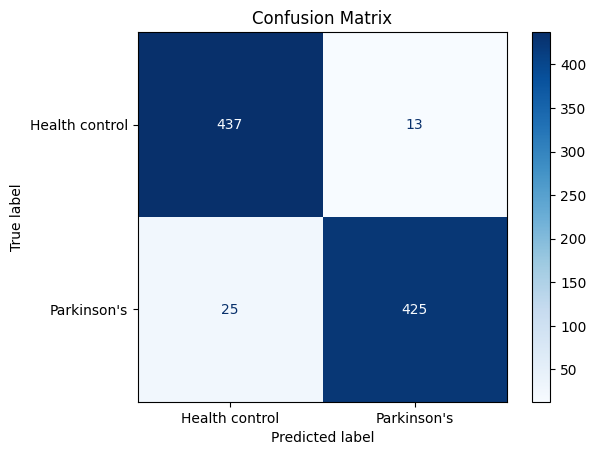

In [ ]:
selected_features = gb_rfecv_selected_features
model = classifiers_hp_tuned['SVM (RBF)']
# model = SVC(kernel='linear', probability=True)
# model.fit(X_df, y_train)
res = evaluate_a_classifiers(X_df, y, groups, selected_features, model)

#Exaplainability

In [ ]:
import shap
model = classifiers_hp_tuned['SVM (RBF)']
model.fit(X_df[gb_rfecv_selected_features], y)
# explainer = shap.Explainer(model, X_df)
# shap_values = explainer(X_df)
# shap.plots.beeswarm(shap_values)

KeyError: 'SVM (RBF)'

In [ ]:
# Use KernelExplainer for non-linear models like SVC with polynomial kernel
X_df_selectedf = X_df[gb_rfecv_selected_features]
explainer = shap.KernelExplainer(model.predict_proba, X_df_selectedf.sample(min(900, len(X_df)), replace=False)) # Use a subset for KernelExplainer

# Ensure shap_values are calculated for the entire dataset
shap_values = explainer.shap_values(X_df_selectedf)

# If shap_values is a list (for multi-class), select the class you want to visualize
# For binary classification, it's usually index 1 for the positive class
shap_values = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.plots.beeswarm(shap_values)

In [ ]:
X_df_selectedf = X_df[rf_rfecv_selected_features]
model = classifiers_hp_tuned['Random Forest']
model.fit(X_df_selectedf, y)
explainer = shap.Explainer(model, X_df_selectedf)
shap_values = explainer(X_df_selectedf)

In [ ]:
import joblib

# 💾 Save SHAP values
joblib.dump(shap_values, result_path+ 'shap_values_rf-feature_rf-classifier.pkl')

['/content/drive/MyDrive/Dataset/Parkinson/Result/shap_values_rf-feature_rf-classifier.pkl']

In [ ]:
y_pred = model.predict(X_df_selectedf)
confusion_matrix = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[450   0]
 [  0 450]]


## Waterfall plot explaining an instance

In [ ]:
print(f"Actual: {y[60]} Predicted: {y_pred[60]}")

Actual: 1 Predicted: 1


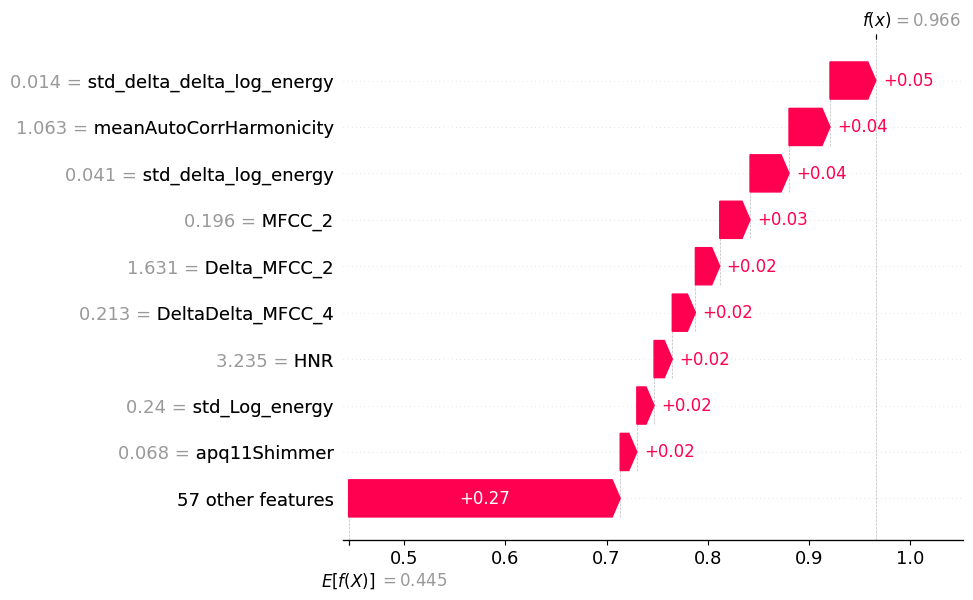

In [ ]:
## the waterfall_plot shows how we get from explainer
shap.plots.waterfall(shap_values[60, :, 1],max_display=10)

##Beeswarm plot

###Display a subset features

In [ ]:
feature_indices = [X_df_selectedf.columns.get_loc(f) for f in dt_rfecv_selected_features]
shap_subset = shap_values[:, feature_indices]

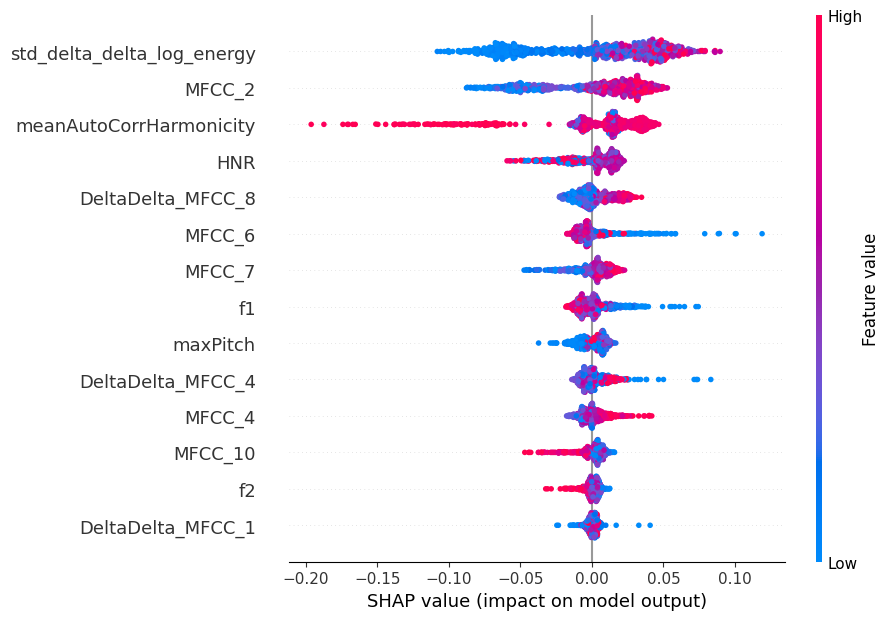

In [ ]:
# # the beeswarm plot displays SHAP values for each feature across all examples,
# with colors indicating how the SHAP values correlate with feature values
shap.plots.beeswarm(shap_subset[:,:,1],max_display=len(dt_rfecv_selected_features))

###Diplay all features

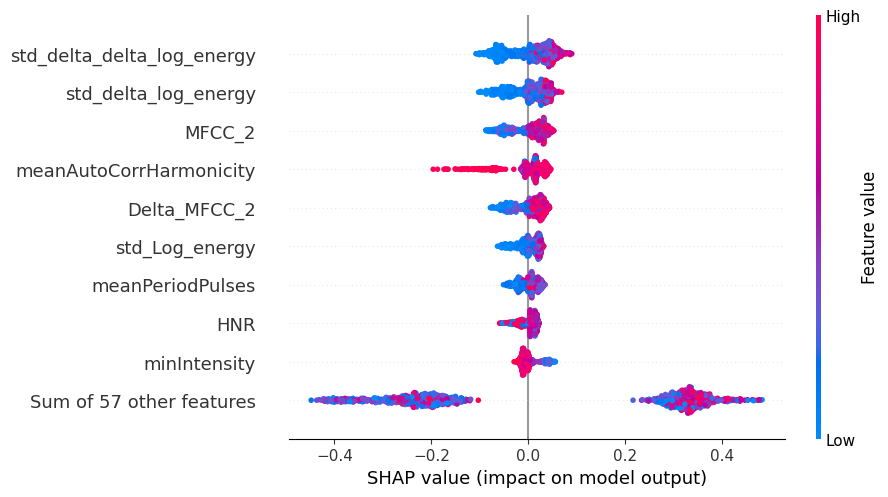

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 1],max_display=10)

###How SHAP select top-k features

In [ ]:
# If using SHAP v0.40+, shap_values is a shap.Explanation object
mean_abs_shap = np.abs(shap_values.values[:, :, 1]).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': X_df_selectedf.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print(importance_df.head(20))  # Top 20

                       Feature  Mean |SHAP|
52  std_delta_delta_log_energy     0.040575
51        std_delta_log_energy     0.030645
55                      MFCC_2     0.029642
13     meanAutoCorrHarmonicity     0.028670
28                Delta_MFCC_2     0.024973
50              std_Log_energy     0.016311
2             meanPeriodPulses     0.015582
24                         HNR     0.013246
16                minIntensity     0.013030
29                Delta_MFCC_3     0.012780
56                      MFCC_3     0.012558
5                 locAbsJitter     0.012282
8                    ddpJitter     0.011594
11                apq11Shimmer     0.011542
6                    rapJitter     0.010984
0                    numPulses     0.010894
1             numPeriodsPulses     0.010536
32                Delta_MFCC_6     0.009633
18               meanIntensity     0.009245
46           DeltaDelta_MFCC_8     0.009234


In [ ]:
import joblib

# 💾 Save SHAP values
joblib.dump(shap_values, result_path+ 'shap_values_svm_.pkl')

# 📂 Load later
shap_values = joblib.load(result_path+'shap_values.pkl')

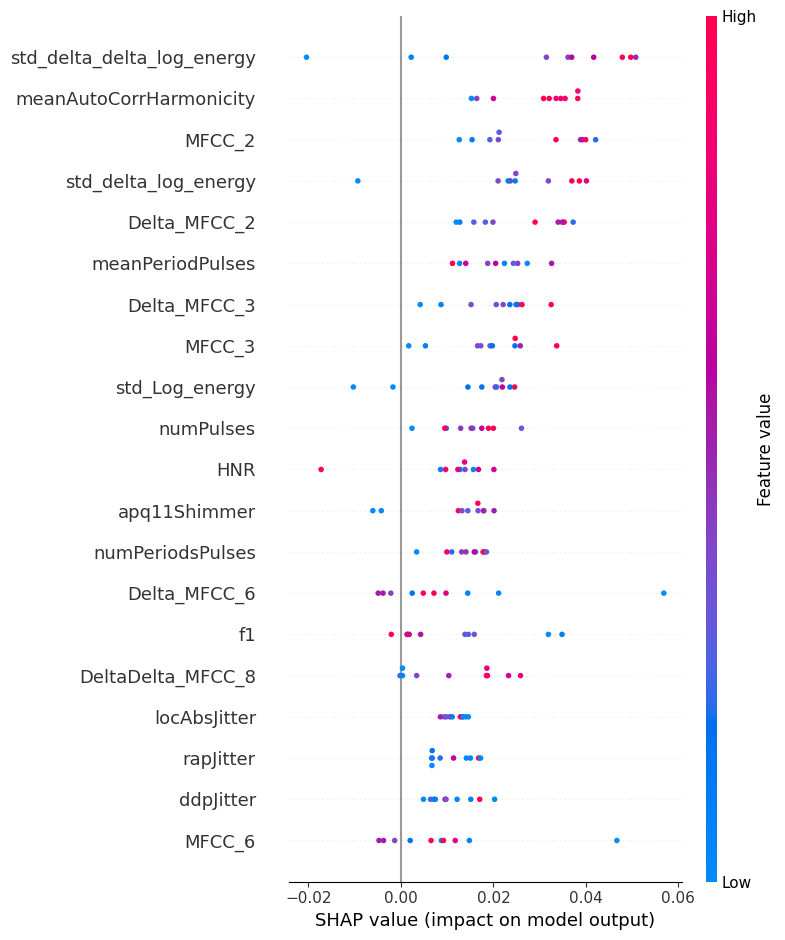

In [ ]:
# Use a sample background set for SHAP
# background = shap.sample(X_train, 100)
# explainer = shap.KernelExplainer(model.predict_proba, background)
shap_values_subset = explainer.shap_values(X_df_selectedf[:10])  # explain just a few for speed

# Visualize
shap.summary_plot(shap_values_subset[:,:,1], X_df_selectedf[:10])  # for class 1

# 1DCNN

In [ ]:
class CNN1D(nn.Module):
    def __init__(self,
            num_classes = 1,
            input_channels = 1
        ):
        super(CNN1D,self).__init__()

        self.num_classes = num_classes
        self.input_channels = input_channels

        # first block of convolutions
        self.conv1 = nn.Conv1d(
            in_channels = self.input_channels,
            out_channels = 16,
            kernel_size = 64
        )
        self.maxpool1 = nn.MaxPool1d(2, stride=2)
        self.bn1 = nn.BatchNorm1d(16)

        # second block of convolutions
        self.conv2 = nn.Conv1d(
            in_channels = 16,
            out_channels = 32,
            kernel_size = 32, padding="same"
        )
        self.maxpool2 = nn.MaxPool1d(2, stride=2)
        self.bn2 = nn.BatchNorm1d(32)

        # third block of convolutions
        self.conv3 = nn.Conv1d(
            in_channels = 32,
            out_channels = 64,
            kernel_size = 16, padding="same"
        )
        self.maxpool3 = nn.MaxPool1d(2, stride=2)
        self.bn3 = nn.BatchNorm1d(64)

        # global average pooling and flattening
        self.glob_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.flatten = nn.Flatten()

        # classifier
        self.linear1 = nn.Linear(64, 128)
        self.linear2 = nn.Linear(128, self.num_classes)
        self.dropout = nn.Dropout(p=0.25)

        self.init_weights()

    def init_weights(self):
        # initialize weights of classifier
        for name, param in self.named_parameters():
            if "weight" in name and len(param.shape) > 1:
                nn.init.xavier_normal_(param)
            elif "bias" in name:
                nn.init.constant_(param, 0)

    def forward(self, input_data):
        # first block of convolutions
        x = F.relu(
            self.conv1(input_data)
        )
        x = self.maxpool1(x)
        x = self.dropout(x)
        x = self.bn1(x)

        # second block of convolutions
        x = F.relu(
            self.conv2(x)
        )
        x = self.maxpool2(x)
        x = self.dropout(x)
        x = self.bn2(x)

        # third block of convolutions
        x = F.relu(
            self.conv3(x)
        )
        x = self.maxpool3(x)
        x = self.dropout(x)
        x = self.bn3(x)
        # global average pooling and flattening
        x = self.glob_avg_pool(x)
        x = self.flatten(x)

        # classifier
        x = self.linear1(x)
        x = self.dropout(x)
        x = self.linear2(x)

        predictions = F.sigmoid(x)
        return predictions


In [ ]:
def initialize_model(learning_rate):
  # Initialize Model, Loss, Optimizer
    model = CNN1D(num_classes=1, input_channels=1)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, criterion, optimizer

In [ ]:
def checking_ids(train_ids, test_ids):
    # Ensure paired IDs are not split across train and test
    print(f"Train IDs: {train_ids}")
    print(f"Test IDs: {test_ids}")
    # Check for overlapping groups
    common_groups = train_ids.intersection(test_ids)
    print(f"Overlapping Groups: {common_groups}")  # SHOULD BE EMPTY
    # Count and print 0 and 1 class in test_ids
    test_df = df[df['group'].isin(test_ids)]
    class_counts = test_df['class'].value_counts()
    print("Class Distribution in Test Set:", class_counts)

# Training parameters

In [ ]:
# Training Parameters
batch_size = 32
learning_rate = 0.001
num_epochs = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Riad's Cross validation

In [ ]:
# Filter for 120 specific IDs (60 PD, 60 Healthy)
selected_ids = np.random.choice(df["group"].unique(), 120, replace=False)
df = df[df["group"].isin(selected_ids)]

# Initialize cross-validation
unique_ids = df["group"].unique()
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# Store fold-wise results
fold_results = []
# Initialize lists to store metrics for each fold
metrics_per_fold = []
# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(kf.split(unique_ids, df.groupby("group")["class"].first().values)):
    train_ids = set(unique_ids[train_idx])
    test_ids = set(unique_ids[test_idx])

    print(f"Fold {fold + 1}:")
    checking_ids(train_ids, test_ids)

    # Ensure paired IDs are not split across train and test
    test_ids_filtered = {id_ for id_ in test_ids if not any(id_.split("_")[0] in train_id for train_id in train_ids)}
    train_ids_filtered = train_ids - test_ids_filtered

    train_df = df[df["group"].isin(train_ids_filtered)]
    test_df = df[df["group"].isin(test_ids_filtered)]

    X_train, y_train = train_df.iloc[:, 1:-2].values, train_df["class"].values
    X_test, y_test, test_ids_list = test_df.iloc[:, 1:-2].values, test_df["class"].values, test_df["id"].tolist()


    # Normalize the feature values
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.fit_transform(X_test)

    X_train = np.expand_dims(X_train, axis=1)  # Adds a channel dimension -> (samples, features, 1)
    X_test = np.expand_dims(X_test, axis=1)



     # Convert to PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Add dim for BCE loss

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    # Create PyTorch Datasets and DataLoaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Print class distribution in this fold
    unique, counts = np.unique(y_test, return_counts=True)
    # print(f"Test Class Distribution: {dict(zip(unique, counts))}")

    # Store results for analysis
    fold_results.append({
        "fold": fold + 1,
        "train_size": len(train_idx),
        "test_size": len(test_idx),
        "class_distribution": dict(zip(unique, counts))
    })

    model, criterion, optimizer = initialize_model(learning_rate=0.001)
     # Training Loop
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

    # Evaluation on Test Set
    model.eval()
    y_pred_probs = []
    y_true = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch).cpu().numpy()

            y_pred_probs.extend(outputs.flatten().tolist())
            y_true.extend(y_batch.numpy().flatten().tolist())

    # Compute metrics
    acc, precision, recall, specificity, f1, roc_auc = compute_metrics(np.array(y_true), np.array(y_pred_probs))

    # Store fold results
    metrics_per_fold.append({
        "Fold": fold + 1,
        "Accuracy": acc,
        "Precision": precision,
        "Recall (Sensitivity)": recall,
        "Specificity": specificity,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

In [ ]:
train_df.iloc[:, 1:-2].values

# Cross validation

In [ ]:
# Reshape X to fit CNN1D: (samples, features, channels)
X = np.expand_dims(X, axis=1)  # Adds a channel dimension -> (samples, features, 1)

# Define GroupKFold for 10 folds
gkf = GroupKFold(n_splits=10)

# Store fold-wise results
fold_results = []
# Initialize lists to store metrics for each fold
metrics_per_fold = []

# Iterate over folds
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    print(f"Fold {fold + 1}:")

    # Split data
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Extract train and test groups
    # train_groups = set(groups[train_idx])
    # test_groups = set(groups[test_idx])

    # Check for overlapping groups
    # common_groups = train_groups.intersection(test_groups)
    # print(f"Overlapping Groups: {common_groups}")  # SHOULD BE EMPTY

    # Convert to PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Add dim for BCE loss

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    # Create PyTorch Datasets and DataLoaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Print class distribution in this fold
    unique, counts = np.unique(y_test, return_counts=True)
    # print(f"Test Class Distribution: {dict(zip(unique, counts))}")

    # Store results for analysis
    fold_results.append({
        "fold": fold + 1,
        "train_size": len(train_idx),
        "test_size": len(test_idx),
        "class_distribution": dict(zip(unique, counts))
    })

    model, criterion, optimizer = initialize_model(learning_rate=0.001)
     # Training Loop
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

    # Evaluation on Test Set
    model.eval()
    y_pred_probs = []
    y_true = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch).cpu().numpy()

            y_pred_probs.extend(outputs.flatten().tolist())
            y_true.extend(y_batch.numpy().flatten().tolist())

    # Compute metrics
    acc, precision, recall, specificity, f1, roc_auc = compute_metrics(np.array(y_true), np.array(y_pred_probs))

    # Store fold results
    metrics_per_fold.append({
        "Fold": fold + 1,
        "Accuracy": acc,
        "Precision": precision,
        "Recall (Sensitivity)": recall,
        "Specificity": specificity,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Convert fold results into a DataFrame
# results_df = pd.DataFrame(fold_results)

# Display results
# import ace_tools as tools
# tools.display_dataframe_to_user(name="Cross-Validation Results", dataframe=results_df)


Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:
Fold 6:
Fold 7:
Fold 8:
Fold 9:
Fold 10:


In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(metrics_per_fold)

# Compute Mean and 95% Confidence Interval (CI)
mean_metrics = results_df.mean(numeric_only=True)
std_metrics = results_df.std(numeric_only=True)
ci_95 = 1.96 * (std_metrics / np.sqrt(10))  # 95% CI = 1.96 * (std_dev / sqrt(n))

# Create summary DataFrame
summary_df = pd.DataFrame({
    "Metric": mean_metrics.index,
    "Mean": mean_metrics.values,
    "95% CI": ci_95.values
})

# Save everything to CSV
results_df.to_csv("fold_results.csv", index=False)
summary_df.to_csv("summary_results.csv", index=False)

In [ ]:
metrics_per_fold

[{'Fold': 1,
  'Accuracy': 0.9850746268656716,
  'Precision': 1.0,
  'Recall (Sensitivity)': 0.9666666666666667,
  'Specificity': 1.0,
  'F1-Score': 0.9830508474576272,
  'ROC-AUC': 0.9864864864864864},
 {'Fold': 2,
  'Accuracy': 0.9222222222222223,
  'Precision': 0.8958333333333334,
  'Recall (Sensitivity)': 0.9555555555555556,
  'Specificity': 0.8888888888888888,
  'F1-Score': 0.9247311827956989,
  'ROC-AUC': 0.9777777777777779},
 {'Fold': 3,
  'Accuracy': 0.925,
  'Precision': 0.9210526315789473,
  'Recall (Sensitivity)': 0.9210526315789473,
  'Specificity': 0.9285714285714286,
  'F1-Score': 0.9210526315789473,
  'ROC-AUC': 0.9799498746867168},
 {'Fold': 4,
  'Accuracy': 0.9506172839506173,
  'Precision': 0.975609756097561,
  'Recall (Sensitivity)': 0.9302325581395349,
  'Specificity': 0.9736842105263158,
  'F1-Score': 0.9523809523809523,
  'ROC-AUC': 0.9883720930232558},
 {'Fold': 5,
  'Accuracy': 0.9,
  'Precision': 0.8888888888888888,
  'Recall (Sensitivity)': 0.9090909090909091,

In [ ]:
summary_df

,Metric,Mean,95% CI
0,Fold,5.500000,1.876557
1,Accuracy,0.900576,0.039197
2,Precision,0.915026,0.035164
3,Recall (Sensitivity),0.888730,0.054199
4,Specificity,0.916329,0.033789
5,F1-Score,0.899741,0.039393
6,ROC-AUC,0.966410,0.013924
